# Parte 3 - Classificação das questões por subárea

Classificação das questões do corpus da parte 1 nas 5 subáreas, com três formas de representar o texto:

- **3a.** Bag of Words + TF-IDF
- **3b.** Word embeddings: modelo estático (spaCy `pt_core_news_lg`) e transformer (BERTimbau)
- **3c.** Comparação dos resultados

Seguimos o notebook de exemplo da disciplina (*Exemplo de Categorização de Texto usando k-nn e Bow com Tfidf*):
mesma divisão treino/teste, `TfidfVectorizer` com as stopwords do spaCy e classificador k-NN. Além do k-NN,
testamos a regressão logística, que costuma funcionar melhor com vetores de muitas dimensões.

In [1]:
import json
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import spacy
from sklearn import neighbors
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from threadpoolctl import threadpool_limits

# No macOS, o k-NN do scikit-learn trava (segmentation fault) depois que o spaCy é carregado, porque as
# bibliotecas usam versões diferentes do OpenMP. Limitar o OpenMP a uma thread resolve.
limite_openmp = threadpool_limits(limits=1, user_api="openmp")

## Leitura do corpus

In [2]:
caminho_json = "../parte 1/corpus/corpus.json"
with open(caminho_json, "r", encoding="utf-8") as f:
    questoes = json.load(f)["questoes"]

print(f"Total de questões: {len(questoes)}")
print("Primeira questão:")
print(f"Subárea: {questoes[0]['subarea']}")
print(f"Enunciado (início): {questoes[0]['enunciado'][:200]}...")

Total de questões: 2506
Primeira questão:
Subárea: banco_de_dados_e_ciencia_de_dados
Enunciado (início): Considere a propriedade de Isolamento das transações ACID nos sistemas gerenciadores de bancos de dados. Um mecanismo usualmente empregado para garantir a integridade dos dados em operações concorrent...


In [3]:
contagem = Counter(q["subarea"] for q in questoes)
for subarea, qtd in contagem.most_common():
    print(f"{subarea}: {qtd} questões")

engenharia_de_software_e_programacao: 727 questões
redes_e_infraestrutura: 669 questões
seguranca_da_informacao: 502 questões
banco_de_dados_e_ciencia_de_dados: 469 questões
governanca_e_gestao_de_ti: 139 questões


Cada questão vira um texto só: enunciado + alternativas.

In [4]:
X = np.array([q["enunciado"] + " " + " ".join(a["texto"] for a in q["alternativas"]) for q in questoes])
y = np.array([q["subarea"] for q in questoes])
ids = np.array([q["id"] for q in questoes])
print(X.shape, y.shape)

(2506,) (2506,)


Divisão treino/teste igual à do notebook da aula: 80/20, estratificada, `random_state=42`.
O teste só é usado no final; os parâmetros são escolhidos com validação cruzada no treino.

In [5]:
X_train, X_test, y_train, y_test, ids_train, ids_test = train_test_split(
    X, y, ids,
    test_size=0.2,
    stratify=y,
    random_state=42
)
print(X_train.shape, X_test.shape)

(2004,) (502,)


## 3a. Bag of Words + TF-IDF

Stopwords do spaCy, como no notebook da aula.

In [6]:
nlp = spacy.load("pt_core_news_lg")
stopwords_spacy = list(nlp.Defaults.stop_words)
print(f"Total de stopwords: {len(stopwords_spacy)}")

Total de stopwords: 416


### Comprimento da BoW

Testamos vários valores de `max_features` (quantidade de termos da BoW) com validação cruzada de 5 partes no
treino. A métrica é o F1-macro, porque as classes são desbalanceadas (Governança tem bem menos questões).

In [7]:
def classificadores():
    return {
        "k-NN (k=3)": neighbors.KNeighborsClassifier(n_neighbors=3),
        "Regressão logística": LogisticRegression(max_iter=2000, class_weight="balanced"),
    }


tamanhos = [200, 500, 1000, 2000, 5000, 10000, None]
tabela = {}
for nome, clf in classificadores().items():
    tabela[nome] = []
    for tamanho in tamanhos:
        pipe = make_pipeline(TfidfVectorizer(stop_words=stopwords_spacy, sublinear_tf=True, max_features=tamanho), clf)
        tabela[nome].append(cross_val_score(pipe, X_train, y_train, cv=5, scoring="f1_macro").mean())

tabela_bow = pd.DataFrame(tabela, index=[str(t) if t else "todas" for t in tamanhos]).round(3)
tabela_bow.index.name = "max_features"
tabela_bow

,k-NN (k=3),Regressão logística
max_features,,
200,0.548,0.791
500,0.515,0.849
1000,0.829,0.890
2000,0.868,0.910
5000,0.889,0.915
10000,0.892,0.914
todas,0.891,0.913


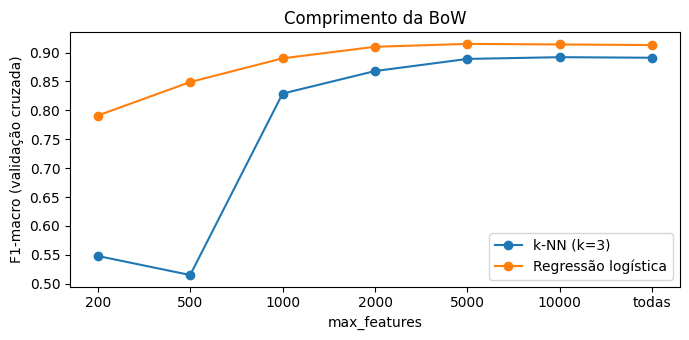

In [8]:
fig, ax = plt.subplots(figsize=(7, 3.5))
for nome in tabela_bow.columns:
    ax.plot(tabela_bow.index, tabela_bow[nome], marker="o", label=nome)
ax.set_xlabel("max_features")
ax.set_ylabel("F1-macro (validação cruzada)")
ax.set_title("Comprimento da BoW")
ax.legend()
plt.tight_layout()
plt.savefig("resultados/comprimento_bow.png", dpi=130)
plt.show()

### Outros parâmetros

Com 10.000 termos, comparamos: com e sem stopwords, unigramas e bigramas, e o `max_df=0.8` do notebook da aula.

In [9]:
variacoes = {
    "sem stopwords": dict(),
    "stopwords do spaCy": dict(stop_words=stopwords_spacy),
    "stopwords + bigramas": dict(stop_words=stopwords_spacy, ngram_range=(1, 2)),
    "stopwords + max_df=0.8": dict(stop_words=stopwords_spacy, max_df=0.8),
}
tabela = {}
for nome, clf in classificadores().items():
    tabela[nome] = []
    for params in variacoes.values():
        pipe = make_pipeline(TfidfVectorizer(sublinear_tf=True, max_features=10000, **params), clf)
        tabela[nome].append(cross_val_score(pipe, X_train, y_train, cv=5, scoring="f1_macro").mean())
pd.DataFrame(tabela, index=list(variacoes)).round(3)

,k-NN (k=3),Regressão logística
sem stopwords,0.888,0.909
stopwords do spaCy,0.892,0.914
stopwords + bigramas,0.876,0.918
stopwords + max_df=0.8,0.892,0.914


### Vetorizador final

Parâmetros escolhidos a partir das tabelas acima: 10.000 termos (depois disso o resultado não melhora),
stopwords do spaCy e só unigramas. Os bigramas melhoram um pouco a regressão logística (0,918 × 0,914), mas
pioram o k-NN (0,876 × 0,892) e deixam o vocabulário bem maior, então ficamos com unigramas.

In [10]:
vectorizer = TfidfVectorizer(
    lowercase=True,               # passa para caixa baixa
    stop_words=stopwords_spacy,   # remove as stopwords do spaCy
    ngram_range=(1, 1),           # só unigramas: bigramas quase não mudam a regressão logística e pioram o k-NN
    max_df=1.0,                   # o max_df=0.8 não mudou nada, então não usamos
    min_df=1,                     # mantém termos que aparecem em pelo menos 1 questão
    max_features=10000,           # comprimento da BoW
    norm="l2",                    # normalização dos vetores
    use_idf=True,                 # usa IDF
    smooth_idf=True,              # evita divisão por zero no IDF
    sublinear_tf=True,            # escala logarítmica na contagem (1 + log(tf))
    strip_accents=None            # mantém os acentos
)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)
print("Shape treino:", X_train_tfidf.shape)
print("Shape teste:", X_test_tfidf.shape)

Shape treino: (2004, 10000)
Shape teste: (502, 10000)


In [11]:
resultados = {}   # F1-macro e acurácia de cada combinação, para a comparação no final
predicoes = {}

def avaliar(nome, clf, X_tr, X_te):
    clf.fit(X_tr, y_train)
    y_pred = clf.predict(X_te)
    resultados[nome] = {"F1-macro": f1_score(y_test, y_pred, average="macro"),
                        "Acurácia": accuracy_score(y_test, y_pred)}
    predicoes[nome] = y_pred
    print(f"=== {nome}")
    print(classification_report(y_test, y_pred, digits=3))
    return clf


avaliar("TF-IDF + k-NN", neighbors.KNeighborsClassifier(n_neighbors=3), X_train_tfidf, X_test_tfidf)
logreg_tfidf = avaliar("TF-IDF + regressão logística",
                       LogisticRegression(max_iter=2000, class_weight="balanced"), X_train_tfidf, X_test_tfidf)

=== TF-IDF + k-NN
                                      precision    recall  f1-score   support

   banco_de_dados_e_ciencia_de_dados      0.874     0.883     0.878        94
engenharia_de_software_e_programacao      0.877     0.925     0.900       146
           governanca_e_gestao_de_ti      0.913     0.750     0.824        28
              redes_e_infraestrutura      0.913     0.866     0.889       134
             seguranca_da_informacao      0.903     0.930     0.916       100

                            accuracy                          0.892       502
                           macro avg      0.896     0.871     0.881       502
                        weighted avg      0.893     0.892     0.892       502



=== TF-IDF + regressão logística
                                      precision    recall  f1-score   support

   banco_de_dados_e_ciencia_de_dados      0.943     0.872     0.906        94
engenharia_de_software_e_programacao      0.890     0.945     0.917       146
           governanca_e_gestao_de_ti      0.893     0.893     0.893        28
              redes_e_infraestrutura      0.903     0.903     0.903       134
             seguranca_da_informacao      0.939     0.920     0.929       100

                            accuracy                          0.912       502
                           macro avg      0.913     0.907     0.910       502
                        weighted avg      0.913     0.912     0.912       502



Termos com mais peso em cada subárea na regressão logística:

In [12]:
termos = vectorizer.get_feature_names_out()
for classe, pesos in zip(logreg_tfidf.classes_, logreg_tfidf.coef_):
    print(f"{classe}: {', '.join(termos[np.argsort(pesos)[-10:][::-1]])}")

banco_de_dados_e_ciencia_de_dados: dados, banco, sql, bancos, tabela, from, select, data, consultas, aprendizado
engenharia_de_software_e_programacao: código, desenvolvimento, software, classe, testes, scrum, java, html, xml, javascript
governanca_e_gestao_de_ti: itil, ti, projeto, cobit, projetos, processos, tecnologia, governança, serviço, bpmn
redes_e_infraestrutura: rede, nuvem, linux, servidor, ip, windows, internet, endereço, redes, protocolo
seguranca_da_informacao: segurança, autenticação, pessoais, ataque, criptografia, acesso, proteção, tratamento, ataques, chave


## 3b. Word embeddings

Cada questão vira um único vetor, e esse vetor entra nos mesmos classificadores. Os modelos não foram
ajustados (sem fine-tuning); só geram os vetores.

### Modelo estático: spaCy `pt_core_news_lg`

O vetor da questão (`doc.vector`) é a média dos vetores de 300 dimensões das palavras.

In [13]:
def vetores_spacy(textos):
    return np.array([doc.vector for doc in nlp.pipe([str(t) for t in textos], batch_size=64)])


X_train_spacy = vetores_spacy(X_train)
X_test_spacy = vetores_spacy(X_test)
print("Shape treino:", X_train_spacy.shape)

avaliar("spaCy + k-NN", neighbors.KNeighborsClassifier(n_neighbors=3), X_train_spacy, X_test_spacy)
avaliar("spaCy + regressão logística",
        make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000, class_weight="balanced", C=0.1)),
        X_train_spacy, X_test_spacy);

Shape treino: (2004, 300)
=== spaCy + k-NN
                                      precision    recall  f1-score   support

   banco_de_dados_e_ciencia_de_dados      0.414     0.511     0.457        94
engenharia_de_software_e_programacao      0.458     0.630     0.530       146
           governanca_e_gestao_de_ti      0.308     0.143     0.195        28
              redes_e_infraestrutura      0.571     0.448     0.502       134
             seguranca_da_informacao      0.552     0.370     0.443       100

                            accuracy                          0.480       502
                           macro avg      0.461     0.420     0.426       502
                        weighted avg      0.490     0.480     0.473       502

=== spaCy + regressão logística
                                      precision    recall  f1-score   support

   banco_de_dados_e_ciencia_de_dados      0.809     0.809     0.809        94
engenharia_de_software_e_programacao      0.851     0.863     0

### Transformer: BERTimbau

Usamos o `neuralmind/bert-base-portuguese-cased` (BERT treinado em português) em vez do `bert-base-uncased`,
que é em inglês. O vetor da questão é a média dos vetores de 768 dimensões dos tokens da última camada,
sem contar o padding. Textos maiores que 512 tokens são cortados.

In [14]:
import torch
from transformers import AutoModel, AutoTokenizer, logging

logging.set_verbosity_error()   # esconde os avisos de carregamento do BERT

tokenizer = AutoTokenizer.from_pretrained("neuralmind/bert-base-portuguese-cased")
bert = AutoModel.from_pretrained("neuralmind/bert-base-portuguese-cased")
bert.eval()


def vetores_bert(textos):
    vetores = []
    with torch.no_grad():
        for i in range(0, len(textos), 16):
            entrada = tokenizer(list(textos[i:i + 16]), padding=True, truncation=True, max_length=512,
                                return_tensors="pt")
            saida = bert(**entrada).last_hidden_state
            mascara = entrada["attention_mask"].unsqueeze(-1)
            vetores.append(((saida * mascara).sum(1) / mascara.sum(1)).numpy())
    return np.vstack(vetores)


X_train_bert = vetores_bert(X_train)
X_test_bert = vetores_bert(X_test)
print("Shape treino:", X_train_bert.shape)

avaliar("BERTimbau + k-NN", neighbors.KNeighborsClassifier(n_neighbors=3), X_train_bert, X_test_bert)
avaliar("BERTimbau + regressão logística",
        make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000, class_weight="balanced", C=0.1)),
        X_train_bert, X_test_bert);

Shape treino: (2004, 768)
=== BERTimbau + k-NN
                                      precision    recall  f1-score   support

   banco_de_dados_e_ciencia_de_dados      0.700     0.745     0.722        94
engenharia_de_software_e_programacao      0.772     0.856     0.812       146
           governanca_e_gestao_de_ti      0.882     0.536     0.667        28
              redes_e_infraestrutura      0.805     0.679     0.737       134
             seguranca_da_informacao      0.791     0.870     0.829       100

                            accuracy                          0.773       502
                           macro avg      0.790     0.737     0.753       502
                        weighted avg      0.777     0.773     0.770       502

=== BERTimbau + regressão logística
                                      precision    recall  f1-score   support

   banco_de_dados_e_ciencia_de_dados      0.783     0.766     0.774        94
engenharia_de_software_e_programacao      0.819     0.8

## 3c. Comparação

In [15]:
comparacao = pd.DataFrame(resultados).T.round(3)
comparacao.to_csv("resultados/comparacao.csv")
comparacao

,F1-macro,Acurácia
TF-IDF + k-NN,0.881,0.892
TF-IDF + regressão logística,0.910,0.912
spaCy + k-NN,0.426,0.480
spaCy + regressão logística,0.832,0.851
BERTimbau + k-NN,0.753,0.773
BERTimbau + regressão logística,0.804,0.813


Matrizes de confusão da regressão logística, que foi o melhor classificador nas três representações:

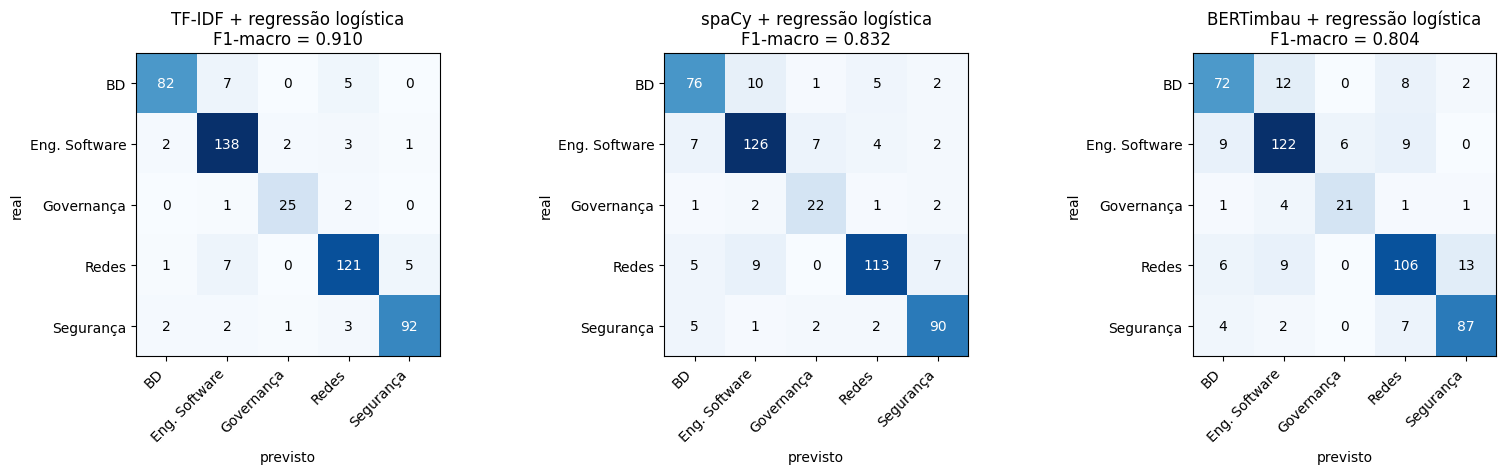

In [16]:
classes = sorted(contagem)
nomes_curtos = ["BD", "Eng. Software", "Governança", "Redes", "Segurança"]
fig, eixos = plt.subplots(1, 3, figsize=(16, 4.8))
for ax, nome in zip(eixos, ["TF-IDF + regressão logística", "spaCy + regressão logística",
                            "BERTimbau + regressão logística"]):
    matriz = confusion_matrix(y_test, predicoes[nome], labels=classes)
    ax.imshow(matriz, cmap="Blues")
    for i in range(5):
        for j in range(5):
            ax.text(j, i, matriz[i, j], ha="center", va="center", color="white" if matriz[i, j] > 60 else "black")
    ax.set_xticks(range(5), nomes_curtos, rotation=45, ha="right")
    ax.set_yticks(range(5), nomes_curtos)
    ax.set_xlabel("previsto")
    ax.set_ylabel("real")
    ax.set_title(f"{nome}\nF1-macro = {resultados[nome]['F1-macro']:.3f}")
plt.tight_layout()
plt.savefig("resultados/matrizes_confusao.png", dpi=130)
plt.show()

Questões do teste que os três modelos (regressão logística) erraram:

In [17]:
erradas = (predicoes["TF-IDF + regressão logística"] != y_test) & \
          (predicoes["spaCy + regressão logística"] != y_test) & \
          (predicoes["BERTimbau + regressão logística"] != y_test)
print(f"Erradas pelos três: {erradas.sum()} de {len(y_test)}")
texto_teste = dict(zip(ids_test, X_test))
pd.DataFrame({
    "id": ids_test[erradas],
    "subárea do corpus": y_test[erradas],
    "previsão TF-IDF": predicoes["TF-IDF + regressão logística"][erradas],
    "início do texto": [texto_teste[i][:120] for i in ids_test[erradas]],
})

Erradas pelos três: 26 de 502


,id,subárea do corpus,previsão TF-IDF,início do texto
0,76-053,banco_de_dados_e_ciencia_de_dados,engenharia_de_software_e_programacao,Após a entrega do sistema de Protocolo Eletrôn...
1,88-048,seguranca_da_informacao,redes_e_infraestrutura,"O formato de arquivo chamado Raw, padrão para ..."
2,56-056,redes_e_infraestrutura,engenharia_de_software_e_programacao,No contexto de processadores modernos que impl...
3,01-040,banco_de_dados_e_ciencia_de_dados,redes_e_infraestrutura,"No contexto das aplicações web, Ajax é uma tec..."
4,52-049,governanca_e_gestao_de_ti,redes_e_infraestrutura,Após uma falha crítica no datacenter principal...
5,62-064,banco_de_dados_e_ciencia_de_dados,redes_e_infraestrutura,Uma equipe foi contratada para resolver o prob...
6,24-057,redes_e_infraestrutura,engenharia_de_software_e_programacao,"No Linux, a função fork cria um novo processo,..."
7,90-034,redes_e_infraestrutura,engenharia_de_software_e_programacao,"Rodrigo preparou um documento no LO Writer, no..."
8,79-069,seguranca_da_informacao,banco_de_dados_e_ciencia_de_dados,"O procedimento forense denominado carving, que..."
9,09-064,redes_e_infraestrutura,seguranca_da_informacao,A arquitetura de segurança X.800 para o modelo...
